# you only look once (YOLO) [🚧 WIP]

Ultralytics supports a wide range of YOLO models, from early versions like [YOLOv3](https://docs.ultralytics.com/models/yolov3/) to the latest [YOLO11](https://docs.ultralytics.com/models/yolo11/). the latest version of the acclaimed real-time object detection and image segmentation model `YOLO11` models pretrained on the [COCO](https://docs.ultralytics.com/datasets/detect/coco/) dataset for [Detection](https://docs.ultralytics.com/tasks/detect/), [Segmentation](https://docs.ultralytics.com/tasks/segment/), and [Pose Estimation](https://docs.ultralytics.com/tasks/pose/). Additionally, [Classification](https://docs.ultralytics.com/tasks/classify/) models pretrained on the [ImageNet](https://docs.ultralytics.com/datasets/classify/imagenet/) dataset are available. [Tracking](https://docs.ultralytics.com/modes/track/) mode is compatible with all Detection, Segmentation, and Pose models. All [Models](https://docs.ultralytics.com/models/) are automatically downloaded from the latest Ultralytics [release](https://github.com/ultralytics/assets/releases) upon first use.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
import torch
import random

In [6]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [3]:
# Initialize detection model
from ultralytics import YOLO
yolo_model = YOLO("yolov8n.pt") 

In [6]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://ultralytics.com/images/bus.jpg' save=True

Ultralytics 8.3.4 🚀 Python-3.12.4 torch-2.4.1 CPU (Apple M3 Max)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100%|█████████████████████████████████████████| 134k/134k [00:00<00:00, 215MB/s]
image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 29.8ms
Speed: 1.6ms preprocess, 29.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /Users/n0man/Code/n03an.me/runs/detect/predict7
💡 Learn more at https://docs.ultralytics.com/modes/predict


set up the device (mps for macOS, cuda for NVIDIA GPUs, or cpu for CPU-only inference)

In [4]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
# Run detection
def detect_objects(image_path):
    results = yolo_model(image_path)
    # Visualize results
    plt.figure(figsize=(12, 8))
    plt.imshow(results[0].plot()[:, :, ::-1])  # Convert BGR to RGB
    plt.title("Object Detection")
    plt.axis('off')
    plt.show()


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 27.2ms
Speed: 1.5ms preprocess, 27.2ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)


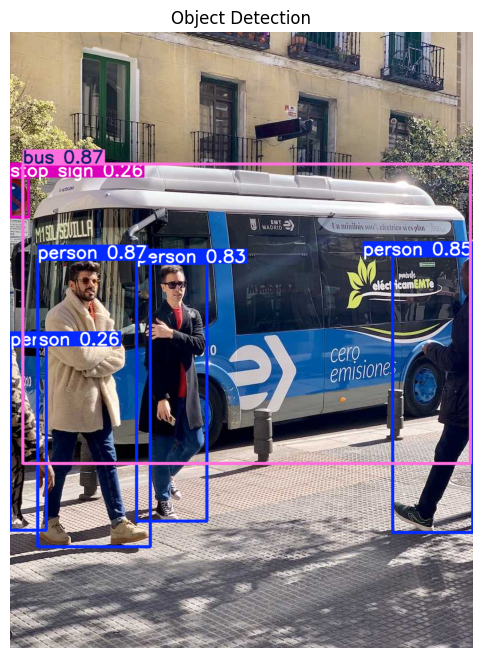

In [6]:
# Run detection
detect_objects("images/bus.jpg")


### Detecting Events

Will try somethin rubbish - the function `detect_event` takes the results from the YOLO model and checks for the presence of specific classes (like "person") to determine interesting event. If there are more than 3 people, it flags it as "fighting", and if there are 5 or more, it flags it as a "crowd" situation 🤦🏻‍♂️🤦🏻‍♂️🤦🏻‍♂️ as rubbish as it could get but you get the point...

In [7]:
FIRE_CLASSES = ["fire", "smoke"]
CROWD_THRESHOLD = 5

def detect_event(yolo_results):
    people_count = 0
    fire_detected = False

    for det in yolo_results.boxes:
        cls = int(det.cls[0])
        label = yolo_model.names[cls]

        if label == "person":
            people_count += 1
        elif label in FIRE_CLASSES:
            fire_detected = True

    fighting_detected = people_count >= 3 and not fire_detected
    overcrowded = people_count >= CROWD_THRESHOLD

    return fire_detected, fighting_detected, overcrowded, people_count

we will use lightweight BLIP model `Salesforce/blip-image-captioning-base` (possibly the one that could run on Jetson edge devies like Jetson Xavier NX??) to generate image captions.

In [8]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image as PILImage

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base", 
    device_map="auto", 
    trust_remote_code=True, 
    use_safetensors=True  # <--- this avoids torch.load
)

def generate_caption(frame):
    pil_image = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = blip_processor(images=pil_image, return_tensors="pt")

    inputs = {k: v.to(device) for k, v in inputs.items()}
    output = blip_model.generate(**inputs, max_new_tokens=50)
    caption = blip_processor.batch_decode(output, skip_special_tokens=True)[0]
    return caption


/Users/n0man/Code/n03an.me/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Detecting Events and Captions...


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 34.6ms
Speed: 2.4ms preprocess, 34.6ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)


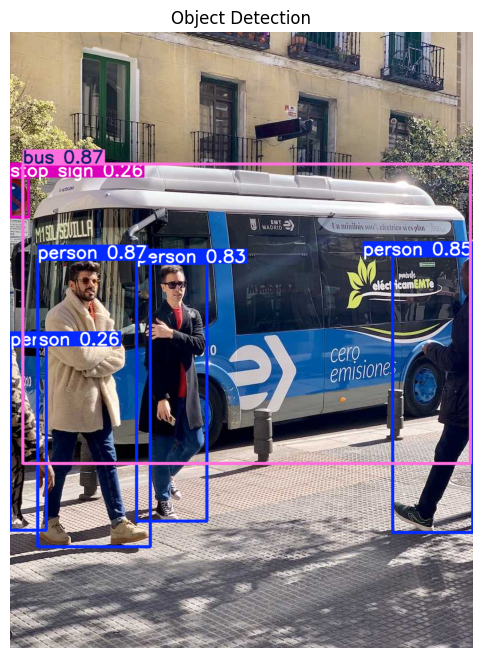


0: 640x480 4 persons, 1 bus, 1 stop sign, 21.7ms
Speed: 1.1ms preprocess, 21.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)

[EVENT DETECTED]
🔴 Possible fighting detected
Captions : a group of people walking around a bus


In [19]:
image_path = "images/bus.jpg"
frame = cv2.imread(image_path)
detect_objects(image_path)

results = yolo_model(frame)[0]
fire, fight, crowd, count = detect_event(results)

if fire or fight or crowd:
    print("\n[EVENT DETECTED]")
    if fire: print("🔥 Fire detected")
    if fight: print("🔴 Possible fighting detected")
    if crowd: print(f"👯👯👯👯 Overcrowding detected ({count} people)")

    caption = generate_caption(frame)
    print(f"Captions : {caption}")
else:
    print("✅ No major event detected in the image.")


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/park.jpg: 384x640 8 persons, 1 bicycle, 1 dog, 26.7ms
Speed: 1.5ms preprocess, 26.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)


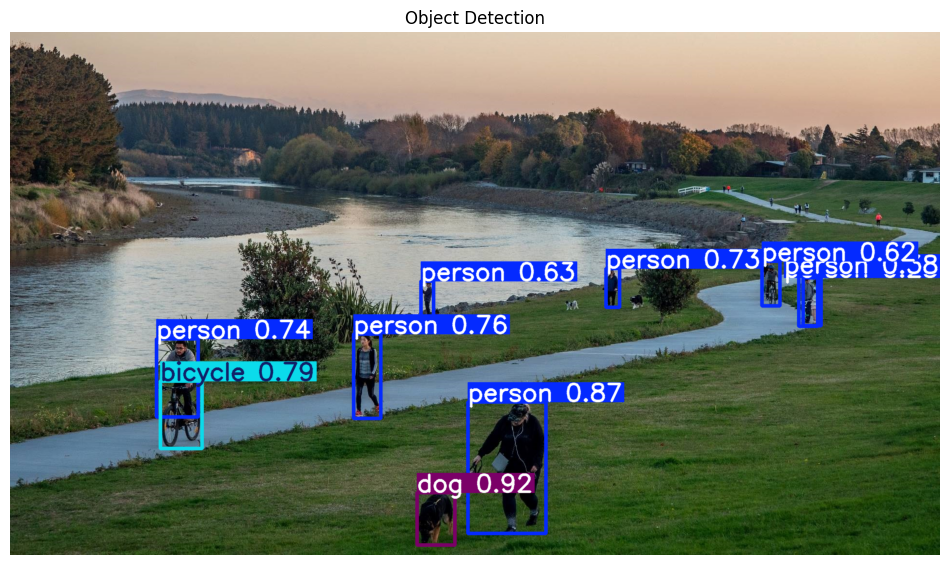


0: 384x640 8 persons, 1 bicycle, 1 dog, 17.2ms
Speed: 1.3ms preprocess, 17.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

[EVENT DETECTED]
🔴 Possible fighting detected
👯👯👯👯 Overcrowding detected (8 people)
Captions : a group of people walking along a river


In [20]:
image_path = "images/park.jpg"
frame = cv2.imread(image_path)
detect_objects(image_path)

results = yolo_model(frame)[0]
fire, fight, crowd, count = detect_event(results)

if fire or fight or crowd:
    print("\n[EVENT DETECTED]")
    if fire: print("🔥 Fire detected")
    if fight: print("🔴 Possible fighting detected")
    if crowd: print(f"👯👯👯👯 Overcrowding detected ({count} people)")

    caption = generate_caption(frame)
    print(f"Captions : {caption}")
else:
    print("✅ No major event detected in the image.")

## Extracting Attributes and meta information using RT-DETR

In [11]:
from ultralytics import RTDETR

# Load a COCO-pretrained RT-DETR-l model
model = RTDETR("rtdetr-l.pt")

100%|██████████| 63.4M/63.4M [00:02<00:00, 29.4MB/s]


In [13]:
# Display model information (optional)
model.info()

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)

# Run inference with the RT-DETR-l model on the 'bus.jpg' image
results = model("images/nemo.png")

rt-detr-l summary: 494 layers, 32,148,140 parameters, 0 gradients, 103.8 GFLOPs
New https://pypi.org/project/ultralytics/8.3.176 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.4 🚀 Python-3.12.4 torch-2.4.1 CPU (Apple M3 Max)
engine/trainer: task=detect, mode=train, model=rtdetr-l.pt, data=coco8.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina

100%|██████████| 433k/433k [00:00<00:00, 11.8MB/s]
Unzipping /Users/n0man/Code/datasets/coco8.zip to /Users/n0man/Code/datasets/coco8...: 100%|██████████| 25/25 [00:00<00:00, 4312.64file/s]

Dataset download success ✅ (0.9s), saved to /Users/n0man/Code/datasets



WARNING ⚠️ no model scale passed. Assuming scale='l'.

                   from  n    params  module                                       arguments                     
  0                  -1  1     25248  ultralytics.nn.modules.block.HGStem          [3, 32, 48]                   
  1                  -1  6    155072  ultralytics.nn.modules.block.HGBlock         [48, 48, 128, 3, 6]           
  2                  -1  1      1408  ultralytics.nn.modules.conv.DWConv           [128, 128, 3, 2, 1, False]    
  3                  -1  6    839296  ultralytics.nn.modules.block.HGBlock         [128, 96, 512, 3, 6]          
  4                  -1  1      5632  ultralytics.nn.modules.conv.DWConv           [512, 512, 3, 2, 1, False]    
  5                  -1  6   1695360  ultralytics.nn.modules.block.HGBlock         [512, 192, 1024, 5, 6, True, False]
  6                  -1  6   2055808  ultralytics.nn.modules.block.HGBlock         [1024, 192, 1024, 5, 6, True, True]
  7                  -1

train: Scanning /Users/n0man/Code/datasets/coco8/labels/train... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<00:00, 2172.65it/s]

...

    100/100         0G     0.6497      1.111     0.6663         13        640: 100%|██████████| 1/1 [00:04<00:00,  4.37s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

                   all          4         17    0.00397     0.0167    0.00235   0.000235



100 epochs completed in 0.165 hours.
Optimizer stripped from /Users/n0man/Code/n03an.me/runs/detect/train/weights/last.pt, 66.5MB
Optimizer stripped from /Users/n0man/Code/n03an.me/runs/detect/train/weights/best.pt, 66.5MB

Validating /Users/n0man/Code/n03an.me/runs/detect/train/weights/best.pt...
Ultralytics 8.3.4 🚀 Python-3.12.4 torch-2.4.1 CPU (Apple M3 Max)
rt-detr-l summary: 502 layers, 32,148,140 parameters, 0 gradients, 103.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


                   all          4         17    0.00538     0.0167     0.0183     0.0039
                person          3         10     0.0323        0.1       0.11     0.0234
                   dog          1          1          0          0          0          0
                 horse          1          2          0          0          0          0
              elephant          1          2          0          0          0          0
              umbrella          1          1          0          0          0          0
          potted plant          1          1          0          0          0          0
Speed: 0.3ms preprocess, 309.9ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /Users/n0man/Code/n03an.me/runs/detect/train

image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/nemo.png: 640x640 4 persons, 1 bicycle, 269.2ms
Speed: 1.2ms preprocess, 269.2ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


In [14]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

In [17]:
def generate_caption(frame):
    pil_image = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    inputs = blip_processor(images=pil_image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    output = blip_model.generate(**inputs, max_new_tokens=50)
    caption = blip_processor.batch_decode(output, skip_special_tokens=True)[0]
    return caption

def extract_color_and_attributes(caption, cls_name):
    colors = ["red", "black", "white", "yellow", "blue", "green", "orange", "pink", "gray", "brown"]
    caption_lower = caption.lower()
    
    color = "unknown"
    for c in colors:
        # check if color near class in caption text
        if c in caption_lower and cls_name.lower() in caption_lower:
            idx_color = caption_lower.find(c)
            idx_cls = caption_lower.find(cls_name.lower())
            if abs(idx_color - idx_cls) < 20:
                color = c
                break

    # Example: detect attribute "white cap" for person
    attributes = []
    if cls_name == "person":
        if "white cap" in caption_lower or "white hat" in caption_lower or "white cap" in caption_lower:
            attributes.append("white cap")
    elif cls_name == "bicycle":
        if "folding" in caption_lower:
            attributes.append("folding")
        if "small wheels" in caption_lower:
            attributes.append("small wheels")

    return color, attributes

def detect_and_caption_objects(frame, yolo_model):
    results = yolo_model(frame)[0]  # assuming yolomodel returns detections in results.boxes

    img_h, img_w = frame.shape[:2]
    detected_objects = []

    for box in results.boxes:
        cls_id = int(box.cls[0])
        cls_name = results.names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        crop = frame[max(0,y1):min(img_h,y2), max(0,x1):min(img_w,x2)]

        caption = generate_caption(crop)

        color, attributes = extract_color_and_attributes(caption, cls_name)

        # Build object dict
        obj = {
            "type": cls_name,
            "color": color,
            "attributes": attributes,
            "caption": caption
        }

        detected_objects.append(obj)

    return detected_objects


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/nemo.png: 640x544 1 person, 1 bicycle, 27.2ms
Speed: 1.7ms preprocess, 27.2ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 544)


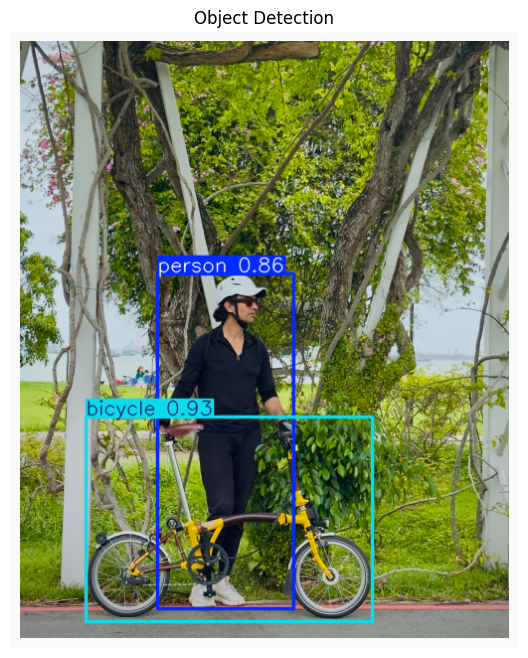


0: 640x544 1 person, 1 bicycle, 33.0ms
Speed: 1.1ms preprocess, 33.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 544)
Object: bicycle, Color: unknown, Attributes: []
Caption: a man standing next to a yellow bike

Object: person, Color: unknown, Attributes: []
Caption: a man riding a bike on a sidewalk



In [21]:
image_path = "images/nemo.png"
frame = cv2.imread(image_path)
detect_objects(image_path)

objects_with_attributes = detect_and_caption_objects(frame, yolo_model)

for obj in objects_with_attributes:
    print(f"Object: {obj['type']}, Color: {obj['color']}, Attributes: {obj['attributes']}")
    print(f"Caption: {obj['caption']}\n")